In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [4]:
importlib.reload(plt_helper)

folder = "/work/bd0620/b309199/linear-mws"

flavors = ["pmap_mpdata", "pmap_ppm", "eulag_compressi", "eulag_anelastic"]
# flavors = ["pmap_mpdata", "pmap_nx2048", "pmap_halfdt", "pmap_1p5dt"]
# flavors = ["pmap_mpdata", "pmap_nocoriolis"]
# flavors = ["eulag_compressi"]

flavor_labels = ["PMAP$_{MPDATA}$", "PMAP$_{PPM}$", "EULAG$_{COMPRESSIBLE}$", "EULAG$_{ANELASTIC}$"]
flavor_labels = flavors

all_ds_lists = {}
all_cfgs = {}

# Lcomp = "001km"
Lcomp = "010km"

for flavor in flavors:
    if Lcomp == "001km":
        sims = [f"{flavor}_MW_001km", f"{flavor}_MW_010km"]
        simlabs = ["L: 1$\,$km", "L: 10$\,$km"]
        # sims = [f"{flavor}_MW_003km", f"{flavor}_MW_003km"]
        # simlabs = ["L: 3$\,$km", "L: 3$\,$km"]
    elif Lcomp == "010km":
        # sims = [f"{flavor}_MW_010km", f"{flavor}_MW_100km"]
        # simlabs = ["L: 10$\,$km", "L: 100$\,$km"]
        sims = [f"{flavor}_MW_010km", f"{flavor}_MW_010km"]
        simlabs = ["L: 10$\,$km", "L: 10$\,$km"]
    ds_list = []
    cfgs = []
    model = flavor.split("_")[0]
    # tstamp = 299
    tstamp = -1
    for sim in sims:
        fpath = os.path.join(folder, sim)
        if model == "pmap":
            ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=tstamp, slices={"x": 0, "y": 0, "z": [0]})
            cfgs.append(cfg)
        else:
            _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, tstamp, slices={"x": 0, "y": 0, "z": [0]})
        ds_list.append(ds)
    all_ds_lists[flavor] = ds_list
    all_cfgs[flavor] = cfgs

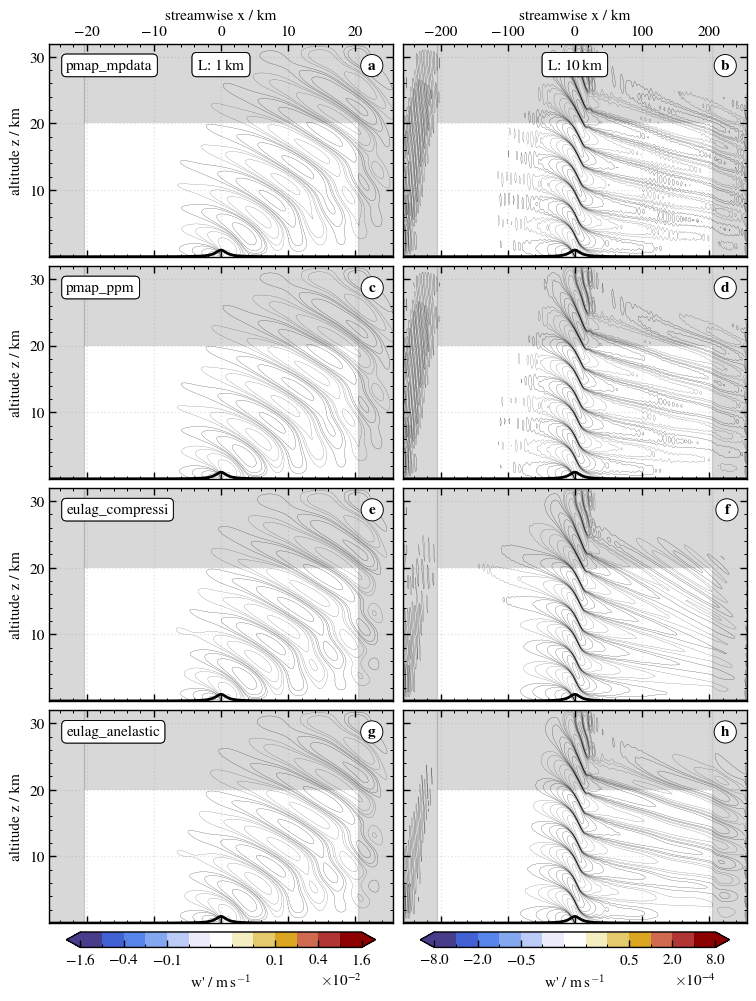

In [3]:
"""EULAG - PMAP comparison plot"""
var0 = "w"
clev = [-16,-8,-4,-2,-1,-0.5,-0.25,0.25,0.5,1,2,4,8,16]
clev_l = [-16,-4,-1,1,4,16]

# div_factor = 10000
if Lcomp == "001km":
    div_factor = 1000
elif Lcomp == "010km":
    div_factor = 10000
clev = np.array(clev) / div_factor
clev_l = np.array(clev_l) / div_factor
cbar_label = r"w' / m$\,$s$^{-1}$"
cmap = cmaps.get_wave_cmap()
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

clev_100   = [-8,-4,-2,-1,-0.5,-0.25,-0.125,0.125,0.25,0.5,1,2,4,8]
clev_l_100 = [-8,-2,-0.5,0.5,2,8]
clev_100 = np.array(clev_100) / div_factor / 10
clev_l_100 = np.array(clev_l_100) / div_factor / 10
norm_100 = BoundaryNorm(boundaries=clev_100, ncolors=cmap.N, clip=True)

clevbase_100 = np.array(clev_100) * 10
clevbase = np.array(clev) * 10

gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [6,6,6,6,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(5,2,figsize=(9,12), gridspec_kw=gskw)

abs_factor = 1
labs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
j = 0
for flavor, ds_list in all_ds_lists.items(): 
    
    cfgs = all_cfgs[flavor]
    model = flavor.split("_")[0]
    for i, ds in enumerate(ds_list):
        if model == "pmap":
            cfg = cfgs[i]
            if cfg['absorber']['xboundaries']:
                nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
                nrelax1 = cfg['nx'] - nrelax0
            else:
                nrelax0 = 0
                nrelax1 = cfg['nx']
            
            zs = ds['zcr'][0,:].values / 1000
            dzdx_surf = np.gradient(zs, cfg['dx'], axis=0)

            wprime = ds['w'].values
            xcr = ds.x / 1000
            zcr = ds['zcr'][:,0].values / 1000
            xsponge = [(ds.x[0] + cfg['absorber']['widthx'])/1000, (ds.x[-1] - cfg['absorber']['widthx'])/1000]
        else:            
            if ds.irelx:
                nrelax0 = int(ds.dxabL/ds.dx00 * abs_factor)
                nrelax1 = ds.nx - nrelax0
            else:
                nrelax0 = 0
                nrelax1 = ds.nx
            zs = ds['zcr'][0,:].values
            wprime = ds['w'].values
            xcr = ds.xcr[0,:].values
            zcr = ds.zcr[:,0]
            xsponge = [ds.xcr[0,0]+ds.dxabL/1000, ds.xcr[0,-1]-ds.dxabR/1000]


        if flavor == "pmap_mpdata":
            if i == 0:
                wprime_ref_10 = wprime
            else:
                wprime_ref_100 = wprime

        if i == 0:
            ## @MB: change wprime!!!
            # wprime_diff = wprime - wprime_ref_10
            wprime_diff = 0 * wprime
            lambdax = 20000
            dx = 500
        else:
            # wprime_diff = wprime - wprime_ref_100
            wprime_diff = 0 * wprime
            lambdax = 200000
            dx = 5000
            
        ifil = 1
        wprime = filter.fil2dx(wprime, ifil=ifil)
        # wprime = filter.gaussian_fft_smoothing(wprime, 1000, lambdax, 50, dx)
        wprime_diff = filter.fil2dx(wprime_diff, ifil=ifil)
        # wprime_diff = filter.gaussian_fft_smoothing(wprime_diff, 1000, lambdax, 50, dx)
        
        if i==0:
            axes[j,i].contour(xcr, zcr, wprime, colors='k', levels=clevbase, linewidths=0.15, extend='both')
            contf = axes[j,i].contourf(xcr, zcr, wprime_diff, cmap=cmap, norm=norm, levels=clev, extend='both')
        else:
            axes[j,i].contour(xcr, zcr, wprime, colors='k', levels=clevbase_100, linewidths=0.15, extend='both')
            contf_100 = axes[j,i].contourf(xcr, zcr, wprime_diff, cmap=cmap, norm=norm_100, levels=clev_100, extend='both')
                
        axes[j,i].plot(xcr, 100 * zs, lw=2, color='black')

        ## Formatting
        xlab = 0.95
        ylab = 0.88
        if i == 0:
            axes[j,i].set_ylabel("altitude z / km")
            axes[j,i].tick_params(which='both', labelbottom=False)
        else:
            axes[j,i].tick_params(which='both', labelleft=False, labelbottom=False)
        if j == 0:
            axes[j,i].set_xlabel("streamwise x / km")
            axes[j,i].xaxis.set_label_position('top')
            axes[j,i].tick_params(which='both', labeltop=True, labelbottom=False)
            axes[j,0].text(0.5, ylab, simlabs[0], horizontalalignment='center', transform=axes[j,0].transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
            axes[j,1].text(0.5, ylab, simlabs[1], horizontalalignment='center', transform=axes[j,1].transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

        axes[j,0].text(1-xlab, ylab, flavor_labels[j], horizontalalignment='left', transform=axes[j,0].transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        axes[j,i].text(xlab, ylab, labs[2*j+i], horizontalalignment='right', transform=axes[j,i].transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

        ## Sponge layer
        alpha_sponge = 0.3
        csponge = "grey"
        
        #ax1.axvline(x=xsponge, lw=1.5,ls='--',color=csponge)
        #ax0.axvline(x=xsponge, lw=1.5,ls='--',color=csponge)
        
        zsponge = [20, np.max(zcr)]
        axes[j,i].fill_between(xsponge, [zsponge[1],zsponge[1]], [zsponge[0],zsponge[0]], facecolor=csponge, alpha=alpha_sponge)
        axes[j,i].axvspan(xcr[0], xsponge[0], alpha=alpha_sponge, color=csponge)
        axes[j,i].axvspan(xsponge[1], xcr[-1], alpha=alpha_sponge, color=csponge)
        # axes[j,i].axvspan(ds.xcr[0,0], ds.xcr[0,0]+ds.dxabL/1000, alpha=alpha_sponge, color=csponge)
        # axes[j,i].axvspan(ds.xcr[0,-1]-ds.dxabR/1000, ds.xcr[0,-1], alpha=alpha_sponge, color=csponge)

    j += 1

for ax in axes.flatten():
    ax.grid()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

#ax1.set_aspect('equal')
#ax3.set_aspect('equal')
for ax in axes[-1,:]:
    ax.set_axis_off()


cbar0 = fig.colorbar(contf, ax=axes[-1, 0], location='bottom',
    fraction=1, shrink=0.9, ticks=clev_l, label=cbar_label, pad=0, extend='both')

cbar1 = fig.colorbar(contf_100, ax=axes[-1, 1], location='bottom',
    fraction=1, shrink=0.9, ticks=clev_l_100, label=cbar_label, pad=0, extend='both')

cbar0.formatter.set_powerlimits((0, 0))
cbar0.formatter.set_useMathText(True)
cbar1.formatter.set_powerlimits((0, 0))
cbar1.formatter.set_useMathText(True)
# ax0.axhline(y=zval, ls='--', lw=2, color='k')

# ax2.text(0.5, ylab, "Residual (PMAP-EULAG)", transform=ax2.transAxes, horizontalalignment="center", bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = f"flavor_comp_w_{Lcomp}.png"
fig_title = f"flavor_comp_w_hf0.png"
# fig_title = f"flavor_comp_w_noCoriolis.png"
# fig_title = f"flavor_comp_w.png"
fig.savefig('../data/pmap/' + fig_title, facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')

In [ ]:
## Horizontal cross sections
ax1.contour(ds.xcr, ds.ycr, arr_eula_xy, colors='k', levels=clev, linewidths=0.1, extend='both')
ax1.contourf(ds_pmap.xcr, ds_pmap.ycr, arr_pmap_xy, cmap=cmap, norm=norm, levels=clev, extend='both')
ax1.contour(ds.xcr, ds.ycr, ds['zs'], levels=[20,40,60,80], colors='k')

ax3.contour(ds.xcr, ds.ycr, ds[var][t,z,:,:], colors='k', levels=clev, linewidths=0.1, extend='both')
ax3.contourf(ds.xcr, ds.ycr, arr_diff_xy, cmap=cmap, norm=norm, levels=clev, extend='both')
ax3.contour(ds.xcr, ds.ycr, ds['zs'], levels=[20,40,60,80], colors='k')

fig.colorbar(contf, ax=axes[0,:], location='top', fraction=1, shrink=0.75, aspect=40, ticks=clev_l, label=cbar_label, extend='both')

ax1.axhline(y=0, lw=1,ls='--',color='k')
ax3.axhline(y=0, lw=1,ls='--',color='k')

## Sponge layer
alpha_sponge = 0.3
csponge = "grey"

#ax1.axvline(x=xsponge, lw=1.5,ls='--',color=csponge)
#ax0.axvline(x=xsponge, lw=1.5,ls='--',color=csponge)
xsponge = [ds.xcr[0,0] + ds.dxabL/1000, ds.xcr[0,-1] - ds.dxabR/1000]
zsponge = [ds.zab/1000, ds.zcr.max().values]
ax0.fill_between(xsponge, [zsponge[1],zsponge[1]], [zsponge[0],zsponge[0]], facecolor=csponge, alpha=alpha_sponge)

ax0.axvspan(ds.xcr[0,0], ds.xcr[0,0]+ds.dxabL/1000, alpha=alpha_sponge, color=csponge)
ax0.axvspan(ds.xcr[0,-1]-ds.dxabR/1000, ds.xcr[0,-1], alpha=alpha_sponge, color=csponge)
ax1.axvspan(ds.xcr[0,0], ds.xcr[0,0]+ds.dxabL/1000, alpha=alpha_sponge, color=csponge)
ax1.axvspan(ds.xcr[0,-1]-ds.dxabR/1000, ds.xcr[0,-1], alpha=alpha_sponge, color=csponge)
ax1.fill_between(xsponge, [ds.ycr[0,0]+ds.dyab/1000,ds.ycr[0,0]+ds.dyab/1000], [ds.ycr[0,0],ds.ycr[0,0]], facecolor=csponge, alpha=alpha_sponge)
ax1.fill_between(xsponge, [ds.ycr[-1,0],ds.ycr[-1,0]], [ds.ycr[-1,0]-ds.dyab/1000,ds.ycr[-1,0]-ds.dyab/1000], facecolor=csponge, alpha=alpha_sponge)


In [ ]:
# xlim  = [ds.xcr.min().values,ds.xcr.max().values]
# ylim  = [ds.ycr.min().values,ds.ycr.max().values]
# zlim  = [0,ds.zcr.max().values]

In [ ]:
"""Notes"""
cfg['ambient_fields']['velocity_x']
cfg['define_orography']['args']
cfg['constants']['fcoriolis0']
cfg['constants']['angle0']